## Exercise Sheet No. 1.5

---

> Machine Learning for Natural Sciences, Summer term 2026, Prof. Pascal Friederich, pascal.friederich@kit.edu
> 
> Deadline: Monday 11.05.2026, 8:00 am
> 
> Tutor: yumeng.zhang@kit.edu
> 
> **Please ask questions in the forum and only contact the Tutor when there are issues with the grading**
---

**Topic**: This exercise sheet will focus on linear algebra, knn classifier, precision, recall, ROC curves and feature reduction. You will continue to use ``numpy`` methods.

Please add here your group members' names and student IDs (up to 3 members per team). 

Names: Bahram Abdullayev

IDs: 2727213

**Each student has to submit their own notebook, even when they worked in a team**

## 1.5.1 Distance function computation

It often happens, whether in the implementation of ML models or when calculating feature descriptors, that we need to compute the mutual Euclidean distance between a set of points. The Euclidean distance of two given data points can serve as a measure of how differently we think they will behave. In this exercise we will focus on an efficient `numpy` implementation of the mutual Euclidean distance between a set of points.

The function ``dist_loop(A,B)`` should compute the Euclidean distance between all elements of two sets of points $A \subset \mathbb{R}^{D}$ and $B \subset \mathbb{R}^{D}$ using explicit python loops, i.e. the distance $d_{ij} = || a_{i} - b_{j} ||$ between all points $a_{i} \in A$ and $b_{j} \in B$. The input should be two matrices of shape $N \times D$ and $M \times D$. The output should be a $N \times M$ distance matrix. For the calculation of the Euclidean distance you might want to use ``numpy.square()``, ``numpy.sum()`` and ``numpy.sqrt()``.

In [28]:
##### DO NOT CHANGE #####
import numpy as np
from numpy import random
import sys
n = 500
m = 1000
d = 3
A_data = np.reshape(random.rand(n*d),(n,d))
B_data = np.reshape(random.rand(m*d),(m,d))

print("A shape:", A_data.shape, "B shape:", B_data.shape)

##### DO NOT CHANGE #####

A shape: (500, 3) B shape: (1000, 3)


<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.1 (3 points).</strong> Implement the function <code>dist_loop(A, B)</code> using explicit Python loops. It should return the matrix of mutual Euclidean distances between every row vector of <code>A</code> (shape <code>N×D</code>) and every row vector of <code>B</code> (shape <code>M×D</code>), i.e. an <code>N×M</code> matrix.
</div>

In [29]:
def dist_loop(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise Euclidean distances using nested Python loops.

    Args:
        A: Array of shape (N, D) with N points in D dimensions.
        B: Array of shape (M, D) with M points in D dimensions.

    Returns:
        Array of shape (N, M) where entry (i, j) is the Euclidean
        distance between ``A[i]`` and ``B[j]``.
    """
    if A.shape[-1] != B.shape[-1]:
        raise ValueError("Error A and B must have same last dimension but got", A.shape[-1], B.shape[-1])

    # YOUR CODE HERE
    N = A.shape[0]
    M = B.shape[0]
    
    distances = np.zeros((N, M))
    
    for i in range(N):
        for j in range(M):
            diff = A[i] - B[j]
            distances[i, j] = np.sqrt(np.sum(np.square(diff)))
    
    return distances


Loops are rather slow in Python, so we would like to have more time-efficient code for our numeric operations. The function ``dist_vec(A,B)`` should compute the same distance relying on vectorization with ``numpy`` methods. Consult https://www.safaribooksonline.com/library/view/python-for-data/9781449323592/ch04.html and https://softwareengineering.stackexchange.com/questions/254475/how-do-i-move-away-from-the-for-loop-school-of-thought if you need more information on how to do this. 

Tip: There is more than one solution. One possible solution involves adding additional dimensions to `np.arrays`, for example using `expand_dims`. In fact, when two `np.arrays` do not have matching shapes they are automatically broadcasted by repeating their respective element along the axis in question. Beside broadcasting, also the [indexing rules](https://numpy.org/doc/stable/reference/arrays.indexing.html) (required for 1.5.2, 1.5.3) of `numpy` help with vectorization to avoid python loops. For this task, you cannot use any ``scipy``  method!

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.2 (3 points).</strong> Implement the function <code>dist_vec(A, B)</code> that computes the same Euclidean distance matrix as <code>dist_loop</code>, but using <code>numpy</code> vectorization (no explicit Python loops, no <code>scipy</code>).
</div>

In [30]:
def dist_vec(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise Euclidean distances using vectorized numpy operations.

    Computes the same result as ``dist_loop`` but without explicit Python
    loops. Use ``np.expand_dims`` (or equivalent broadcasting) to subtract
    every row of ``A`` from every row of ``B`` in one step.

    Args:
        A: Array of shape (N, D).
        B: Array of shape (M, D).

    Returns:
        Array of shape (N, M) where entry (i, j) is the Euclidean
        distance between ``A[i]`` and ``B[j]``.
    """
    # YOUR CODE HERE
    if A.shape[-1] != B.shape[-1]:
        raise ValueError("Error A and B must have same last dimension but got", A.shape[-1], B.shape[-1])
    
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=-1))
    
    return distances


Let's check that the two functions return the same result. Then for each method, assign the shape of the output to the respective variable.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.3 (3 points).</strong> Verify that <code>dist_loop</code> and <code>dist_vec</code> return the same result, then assign the shape of each output to <code>result_loop_shape</code> and <code>result_vec_shape</code>.
</div>

In [31]:
result_loop = dist_loop(A_data, B_data)
result_vec = dist_vec(A_data, B_data)

result_vec_shape = None  # Check shape of result_vec
result_loop_shape = None  # Check shape of result_loop

# YOUR CODE HERE
np.testing.assert_allclose(result_loop, result_vec)

result_vec_shape = result_vec.shape
result_loop_shape = result_loop.shape



Now compare the run times of the two implementations using jupyter's ``%timeit`` command or pythons ``time``. How much faster is the vectorized version?

In [32]:
##### DO NOT CHANGE #####
# measure time for loop
%timeit result_loop = dist_loop(A_data,B_data)
# measure time for vectorized
%timeit result_vec = dist_vec(A_data,B_data)

##### DO NOT CHANGE #####

2.3 s ± 11.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
16.9 ms ± 64.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.4 (1 point).</strong> Run the <code>%timeit</code> cell above first, then estimate roughly by what factor the vectorized implementation is faster than the loop-based one and assign your estimate to <code>speed_up_factor</code>. A rough order-of-magnitude estimate is enough.
</div>

In [33]:
# Assign your estimate of the speed-up factor (loop_time / vec_time) below.
# Order of magnitude is what matters — assign an integer (e.g. 50, 100, 250).
speed_up_factor = 143

# YOUR CODE HERE


Note: It is very important that you understand vectorization, indexing and broadcasting. All deep learning frameworks are based on tensor (array) operations, just like the one you implemented using ``numpy``.

In [34]:
##### DO NOT CHANGE #####
# ID: test-1-5-1-dist-loop - possible points: 3

# Test for grading
assert callable(dist_loop)
assert dist_loop(np.reshape(np.arange(12),(4,3)),np.reshape(np.arange(6),(2,3))).shape==(4,2), 'wrong distance matrix dimensions'

# Pythagoras: distance between (0,0) and (3,4) is 5
d = dist_loop(np.array([[0., 0.]]), np.array([[3., 4.]]))
assert np.isclose(d[0, 0], 5.0), f"expected 5.0, got {d[0, 0]}"

# Distance from a point to itself is 0
P = np.array([[1., 2.], [4., 5.], [7., -1.]])
assert np.allclose(np.diag(dist_loop(P, P)), 0.0), "diagonal of dist_loop(P, P) should be zero"

# Hidden tests verify correctness against an independent reference (and forbid scipy in student code)

##### DO NOT CHANGE #####

In [35]:
##### DO NOT CHANGE #####
# ID: test-1-5-2-dist-vec - possible points: 3

assert callable(dist_vec)

# Pythagoras: distance between (0,0) and (3,4) is 5
d = dist_vec(np.array([[0., 0.]]), np.array([[3., 4.]]))
assert d.shape == (1, 1), \
    f"dist_vec should return a (len(A), len(B)) matrix — got shape {d.shape}"
assert np.isclose(d[0, 0], 5.0), \
    f"dist_vec([[0,0]], [[3,4]]) should be 5.0 (Pythagoras) — got {d[0, 0]}"

# Distance from a set of points to itself: diagonal must be 0
P = np.array([[1., 2.], [4., 5.], [7., -1.]])
assert np.allclose(np.diag(dist_vec(P, P)), 0.0), \
    "distance from a point to itself must be 0 — diagonal of dist_vec(P, P) should be all zeros"

# dist_vec must agree with dist_loop on a small input
S = np.random.RandomState(0).randn(4, 3)
assert np.allclose(dist_loop(S, S), dist_vec(S, S)), \
    "dist_vec should produce the same values as dist_loop — they compute the same quantity"

# Hidden tests verify correctness against an independent reference (and forbid scipy in student code)

##### DO NOT CHANGE #####

In [36]:
##### DO NOT CHANGE #####
# ID: test-1-5-3-equal - possible points: 1

# Test for grading
assert result_loop is not None
assert result_vec is not None

# Both methods compute the same quantity, so they should agree
assert np.allclose(result_loop, result_vec, atol=1e-5), "result_loop and result_vec should match"

# Hidden tests verify correctness against an independent reference

##### DO NOT CHANGE #####

In [37]:
##### DO NOT CHANGE #####
# ID: test-1-5-3-shape - possible points: 2

assert result_vec_shape is not None
assert result_loop_shape is not None

# Both functions compute the same quantity, so their output shapes must match
assert isinstance(result_vec_shape, tuple) and len(result_vec_shape) == 2, "result_vec_shape should be a 2-tuple"
assert isinstance(result_loop_shape, tuple) and len(result_loop_shape) == 2, "result_loop_shape should be a 2-tuple"
assert result_vec_shape == result_loop_shape, f"shapes should match, got {result_vec_shape} vs {result_loop_shape}"

# Hidden tests to check that the functions returned outputs with correct shape

##### DO NOT CHANGE #####

In [38]:
##### DO NOT CHANGE #####
# ID: test-1-5-4-speed-up - possible points: 1

# Test for grading
assert speed_up_factor is not None, "speed_up_factor was not set"
assert speed_up_factor > 5, f"speed_up_factor = {speed_up_factor}, expected the vectorized version to be much faster"

# Hidden test to check if speed up factor lies on an expected interval

##### DO NOT CHANGE #####

## 1.5.2 Precision-Recall Curves

In this section, we will use a synthetic dataset generated with sklearn to represent different configurations of a molecular system.  
Each data point is described by numerical features (e.g., energy and bond length) and belongs to a specific class corresponding to a type of configuration. <br>

We will use a simple distance-based classifier to assign each data point to a class based on similarity.  
To mimic a realistic scenario, we will only use a small subset of labeled data for training and then apply the model to the remaining data points. <br>

To compare data points, we need a measure of similarity: we will use the Euclidean distance, as implemented in the previous section. <br>

Let’s start by generating the dataset, splitting it into a training and a test set, and visualizing the data in feature space.

Train set shape: (420, 3); test set shape: (140, 3)


Example of classes: [1 1 2]


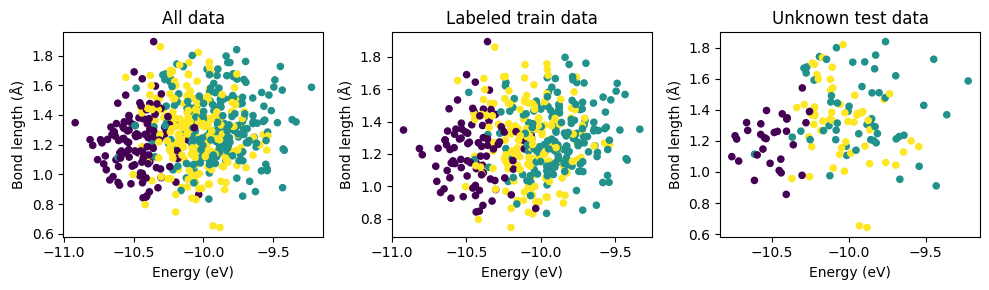

In [39]:
##### DO NOT CHANGE #####
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# fixed random seed
rng = np.random.default_rng(42)

# generate controlled overlapping blob data
# features: [energy (eV), bond length (Å)]
data, target = make_blobs(
    n_samples=[120, 220, 220],   # class imbalance, but deterministic
    centers=[
        [-10.45, 1.20],   # class 0
        [-9.90, 1.34],    # class 1
        [-10.10, 1.28],   # class 2
    ],
    cluster_std=[
        0.18,
        0.22,
        0.22,
    ],
    random_state=42
)

# add one deterministic noisy feature
noise = rng.normal(loc=0.0, scale=0.35, size=(len(data), 1))
data = np.hstack([data, noise])



# split data in train and test set
# stratify keeps class proportions stable
X_labeled, X_unknown, y_labeled, y_unknown = train_test_split(
    data,
    target,
    test_size=0.25,
    random_state=42,
    stratify=target
)

print(f'Train set shape: {X_labeled.shape}; test set shape: {X_unknown.shape}\n\n')
print(f'Example of classes: {target[:3]}')

fig = plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.scatter(data[:, 0], data[:, 1], c=target, cmap="viridis", s=20)
plt.xlabel("Energy (eV)")
plt.ylabel("Bond length (Å)")
plt.title("All data")

plt.subplot(1, 3, 2)
plt.scatter(X_labeled[:, 0], X_labeled[:, 1], c=y_labeled, cmap="viridis", s=20)
plt.xlabel("Energy (eV)")
plt.ylabel("Bond length (Å)")
plt.title("Labeled train data")

plt.subplot(1, 3, 3)
plt.scatter(X_unknown[:, 0], X_unknown[:, 1], c=y_unknown, cmap="viridis", s=20)
plt.xlabel("Energy (eV)")
plt.ylabel("Bond length (Å)")
plt.title("Unknown test data")

fig.tight_layout()
plt.show()

##### DO NOT CHANGE #####

$\textbf{k-NN}$ is a simple non-parametric model. For each datapoint in the test set we want to build a list, sorted by the chosen similarity measure, of all the datapoints in the train set. Then the output of the classifier is determined by the "votes" of the k closest train datapoints, of which we assume we know the correct label. For example we can simply select as predicted class the most common class among the closest neighbors, with a majority vote. Or, in a binary classification setting, define the probability of an object to belong to a given class as the normalized number of positive votes and then predict positively if the probability is over a pre-set threshold.

Let's implement a simple k-NN classifier that can work both for a multiclass setting and as binary classifier when we specify a class of interest. We will use the binary classifier to discuss some common performance metrics later on.

As introduced above, we will use the Euclidean distance between feature vectors as similarity measure:

$d(X_i,X_{i'} ) = || X_i - X_{i'}||_2$

To efficiently compute these distances, you should use vectorization from exercise 1.5.1. Let $D$
be the full dissimilarity matrix, i.e. $D_{i i'} = d(X_i,X_{i'})$. An ``np.argsort()`` of row $D_i$ now gives the similarity ordering, relative to sample $X_i$, of all samples $X_{i'}$ in the train set.


Note: If you didn't manage to solve 1.5.1 you can now use `scipy.spatial.distance.cdist`. But you do not get points for this solution in 1.5.1.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.5 (3 points).</strong> Complete the missing parts of the <code>Knn_Classifier</code> class: compute the distance matrix <code>D</code>, the neighbor ordering <code>nn</code> and the list of neighbor labels <code>self.nn_targets</code> in <code>__init__</code>, and the restricted <code>self.knn_targets</code> in <code>set_k</code>.
</div>

In [40]:
from collections import Counter
from scipy.spatial.distance import cdist


class Knn_Classifier:
    """Simple k-Nearest-Neighbors classifier built on top of pairwise
    Euclidean distances (computed via ``scipy.spatial.distance.cdist``).

    The constructor precomputes, for every test point, the labels of all
    training points sorted from closest to furthest. ``set_k`` then truncates
    these to the ``k`` nearest. Calling the instance returns either a
    multiclass prediction (most-common vote) or a binary prediction for a
    chosen class above a probability threshold.
    """

    def __init__(self, X_unknown: np.ndarray, X_labeled: np.ndarray, y_labeled: np.ndarray):
        """Precompute the sorted neighbor labels for every test point.

        Args:
            X_unknown: Array of shape (N_unknown, D) with unlabeled query points.
            X_labeled: Array of shape (N_labeled, D) with the training points.
            y_labeled: Array of shape (N_labeled,) with integer class labels.
        """
        D = None                # compute distances from each X_unknown to each X_labeled
        nn = None               # order neighbors from closest to furthest
        self.nn_targets = None  # 2-D array of shape (N_unknown, N_labeled): labels (our 'votes') of the ordered neighbors

        # YOUR CODE HERE
        D = dist_vec(X_unknown, X_labeled)
        nn = np.argsort(D, axis=1)
        self.nn_targets = y_labeled[nn]

    def set_k(self, k: int) -> None:
        """Restrict the stored neighbors to the ``k`` closest per test point.

        Args:
            k: Number of nearest neighbors to keep for the vote.
        """
        self.knn_targets = None  # restrict list of labels to k closest neighbors

        # YOUR CODE HERE
        self.knn_targets = self.nn_targets[:, :k]

        

    def __call__(self, label: int | None = None, threshold: float = .5):
        """Predict labels for the test points.

        Args:
            label: If ``None``, return multiclass predictions
                (most-common vote among the k neighbors). Otherwise treat
                ``label`` as the positive class for binary classification.
            threshold: Probability threshold for binary classification
                (only used when ``label`` is not ``None``).

        Returns:
            Multiclass: array of shape (N_unknown,) with predicted labels.
            Binary: tuple ``(preds, probs)`` of two arrays of shape
            (N_unknown,): the binary predictions and the per-point class
            probabilities for ``label``.
        """
        counters = [Counter(self.knn_targets[i]) for i in range(self.knn_targets.shape[0])]
        if label is None:
            # multiclass classifier, for each data point it outputs the most "voted" class by the neighbors
            preds = np.asarray([c.most_common(1)[0][0] for c in counters])
            return preds
        else:
            # binary classifier for class 'label'
            # computes the probability a given data point belongs to a class or to any of the others
            # as the number of votes for that class normalized over the total number of votes
            probs = np.asarray([c.get(label, 0)/sum(c.values()) for c in counters])
            # predicts as belonging to the class 'label' if the computed probability exceeds the threshold
            preds = (probs >= threshold).astype(int)
            return preds, probs


Let's run a multiclass knn classification setting the number of neighbors k to 5. 

To have an overview of the goodness of the classification we will print a $\textbf{confusion matrix}$. A confusion matrix is defined as the matrix $C$ such that $C_{ij}$ is equal to the number of observations known to be in group $i$ and predicted to be in group $j$. It can be easily computed using the function "confusion_matrix" from sklearn.metrics and we'll plot it using seaborn heatmaps.

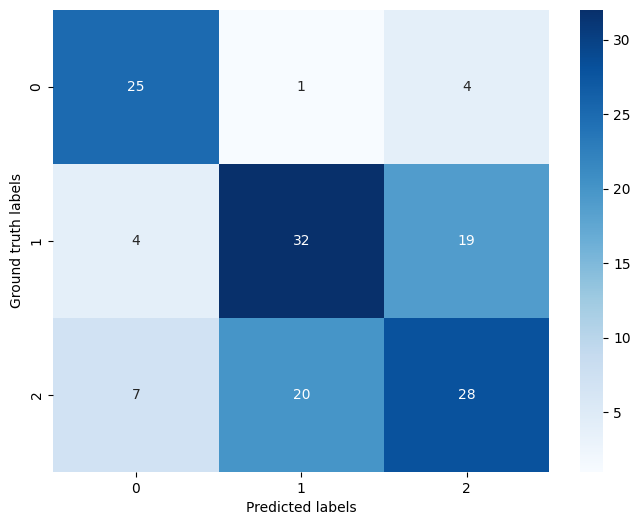

In [41]:
##### DO NOT CHANGE #####
import seaborn as sns
from sklearn.metrics import confusion_matrix

knn = Knn_Classifier(X_unknown, X_labeled, y_labeled)
knn.set_k(5)
preds = knn()
cf_matrix = confusion_matrix(y_unknown, preds)

fig, ax = plt.subplots(figsize=(8,6))
ax = sns.heatmap(cf_matrix, annot=True, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('Ground truth labels')
plt.show()
plt.close()

##### DO NOT CHANGE #####

Each row of the confusion matrix represents the instances in an actual class while each column represents the instances in a predicted class. Once produced, we can use it directly to compute some performance measures. We will have a look at two evaluation metrics used to assess the performance of a machine learning model in a binary classification problem: precision and recall. 

In a binary setting, so considering in our example one class against all other classes, we can define:

1. true positives (TP): number of objects belonging to the class that were **correctly** predicted as belonging to it;
2. true negatives (TN): number of objects **not** belonging to the class that were **correctly** predicted as **not** belonging to it;
3. false positives (FP): number of objects **not** belonging to the class that were **incorrectly** predicted as belonging to it;
4. false negatives (FN): number of objects belonging to the class that were **incorrectly** predicted as **not** belonging to it;

Given these four quantities we can define:

1. **Precision**, or positive predictive value, is the proportion of true positive predictions among all the positive predictions made by the model. In formulas: $\text{precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$
2. **Recall**, also termed sensitivity or probability of detection, is the proportion of true positive predictions among all the actual positive cases in the dataset. In formulas: $\text{recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$.

A high precision indicates that the model is making few false positive predictions, i.e., positive predictions are correct. A high recall indicates that the model is making few false negative predictions, i.e., the model is correctly identifying all positive cases in the dataset. Ideally we would like both of these measures to be equal to 1, meaning that all objects predicted as belonging to the class are actually from that class (precision=1) and all objects belonging to the class are correctly predicted as belonging to it (recall=1). In general, there is a trade-off between precision and recall: increasing one metric often comes at the expense of the other.  

Let's compute precision and recall of our multiclass k-NN classifier using the confusion matrix we computed above.


In [42]:
for label in range(3):
    print(f'Performance of multiclass classifier for label {label} VS all others:')
    # to access predictions relative to a given class i we select the i-th column of the confusion matrix
    column_counts = cf_matrix[:, label]
    # the i-th row corresponds to the samples actually belonging to class i 
    row_counts = cf_matrix[label]

    TP = column_counts[label]
    FP = sum(column_counts) - column_counts[label]
    FN = sum(row_counts) - row_counts[label]
    
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)

    print(f'\t-True positives: {TP}')
    print(f'\t-False positives: {FP}')
    print(f'\t-False negatives: {FN}')
    print(f'\t-Precision: {precision:.2f}')
    print(f'\t-Recall: {recall:.2f}')

Performance of multiclass classifier for label 0 VS all others:
	-True positives: 25
	-False positives: 11
	-False negatives: 5
	-Precision: 0.69
	-Recall: 0.83
Performance of multiclass classifier for label 1 VS all others:
	-True positives: 32
	-False positives: 21
	-False negatives: 23
	-Precision: 0.60
	-Recall: 0.58
Performance of multiclass classifier for label 2 VS all others:
	-True positives: 28
	-False positives: 23
	-False negatives: 27
	-Precision: 0.55
	-Recall: 0.51


We have seen how to compute precision and recall with respect to each class using the confusion matrix produced in our multiclass setting. We are now going to switch to binary classification and metrics to introduce a useful tool, the receiver operating characteristic curve, or ROC curve. The ROC curve is a graphical representation of the performance of a binary classifier system as its discrimination threshold is varied. It plots the true positive rate (TPR), which is another name for the recall, against the false positive rate (FPR) at various classification thresholds.

We need now to define a new measure. The FPR, also termed fall-out or false alarm ratio, measures the proportion of negative cases that are incorrectly classified as positive, in formulas $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$.

Let's implement a function that given a k-NN model, the label of interest and a classification threshold, computes all the performance measures we discussed until now.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.6 (2 points).</strong> Implement <code>compute_binary_metrics</code> so that it fills in the true/false positives, true/false negatives and the fall-out (false positive rate) for the given binary classification setting.
</div>

In [43]:
def compute_binary_metrics(knn: Knn_Classifier,
                           label: int,
                           ground_truth: np.ndarray,
                           threshold: float = .3) -> dict:
    """Compute binary-classification metrics for a single class label.

    Treats ``label`` as the positive class and everything else as negative,
    then returns counts of true / false positives / negatives along with
    precision, recall and fall-out (false-positive rate).

    Args:
        knn: Trained ``Knn_Classifier`` instance with ``set_k`` already called.
        label: Positive class label.
        ground_truth: Array of shape (N_unknown,) with true labels.
        threshold: Probability threshold for the binary classifier.

    Returns:
        Dict with keys ``TP``, ``FP``, ``TN``, ``FN``, ``precision``,
        ``recall``, ``fall-out``.
    """
    metrics = {}
    preds, probs = knn(label, threshold)
    target = (ground_truth == label).astype(int)

    metrics['TP'] = None  # true_positives
    metrics['FP'] = None  # false_positives
    metrics['TN'] = None  # true_negative
    metrics['FN'] = None  # false_negatives

    # YOUR CODE HERE
    metrics['TP'] = np.sum((preds == 1) & (target == 1))
    metrics['FP'] = np.sum((preds == 1) & (target == 0))
    metrics['TN'] = np.sum((preds == 0) & (target == 0))
    metrics['FN'] = np.sum((preds == 0) & (target == 1))

    metrics['precision'] = metrics['TP'] / (metrics['TP'] + metrics['FP']) if metrics['TP'] > 0 else 0
    metrics['recall'] = metrics['TP'] / (metrics['TP'] + metrics['FN']) if metrics['TP'] > 0 else 0
    metrics['fall-out'] = None

    # YOUR CODE HERE
    metrics['fall-out'] = metrics['FP'] / (metrics['FP'] + metrics['TN']) if metrics['FP'] > 0 else 0
    

    return metrics


Let's test our function and compare the metrics with the previously computed ones. 

What is different now, with respect to the multiclass setting, is that we can set a classification threshold. Check how changing the threshold changes the values of our metrics.

In [44]:
# modify the threshold_ parameter within the interval (0,1)
# see how the metrics are affected
threshold_ = .3  
knn.set_k(5)
for label in range(3):
    print(f'Performance of binary classifier for label {label}:')
    metrics = compute_binary_metrics(knn, label, y_unknown, threshold=threshold_)
    for k, v in metrics.items():
        print(f'\t-{k}: {v:.2f}')

Performance of binary classifier for label 0:
	-TP: 29.00
	-FP: 15.00
	-TN: 95.00
	-FN: 1.00
	-precision: 0.66
	-recall: 0.97
	-fall-out: 0.14
Performance of binary classifier for label 1:
	-TP: 42.00
	-FP: 34.00
	-TN: 51.00
	-FN: 13.00
	-precision: 0.55
	-recall: 0.76
	-fall-out: 0.40
Performance of binary classifier for label 2:
	-TP: 40.00
	-FP: 41.00
	-TN: 44.00
	-FN: 15.00
	-precision: 0.49
	-recall: 0.73
	-fall-out: 0.48


Now, we can use these binary metrics to compute overall multi-class metrics using the following aggregation methods:

1. **Micro-averaging:** In micro-averaging, we aggregate the binary metrics over all the classes. This means that we sum up the number of true positives, false positives, false negatives, and true negatives over all the classes and then compute the performance metrics.
2. **Macro-averaging:** In macro-averaging, we compute the binary metrics, e.g. precision, for each class separately and then take the average across all the classes. Macro-averaging gives equal weight to all classes and is suitable when we want to evaluate the performance of each class separately.
3. **Weighted averaging:** In weighted averaging, we compute the binary metrics for each class separately and then take the weighted average across all the classes. The weight of each class is proportional to the number of samples from that class in the dataset. Weighted averaging is most suitable averaging technique when the dataset is unbalanced among the various classes.

We can use the function below to compute multi-class performance measures, aggregating the corresponding binary metrics with weighted averaging.


In [45]:
##### DO NOT CHANGE #####
def compute_multiclass_metrics(knn: Knn_Classifier,
                               ground_truth: np.ndarray,
                               threshold: float = .3,
                               labels: np.ndarray = np.arange(3)) -> tuple:
    """Aggregate per-class binary metrics into multiclass averages.

    Computes ``compute_binary_metrics`` for each class in ``labels`` and
    returns a sample-weighted average of precision, recall and fall-out
    alongside the per-class metric dicts. The weight of each class is the
    number of samples in ``ground_truth`` belonging to that class.

    Args:
        knn: Trained ``Knn_Classifier`` instance with ``set_k`` already called.
        ground_truth: Array of shape (N_unknown,) with true labels.
        threshold: Probability threshold passed through to the binary classifier.
        labels: Iterable of class labels to aggregate over.

    Returns:
        Tuple ``(multiclass_metrics, metrics_list)`` where
        ``multiclass_metrics`` is a dict with the weighted averages of
        ``precision``, ``recall`` and ``fall-out``, and ``metrics_list`` is
        the list of per-class dicts as returned by ``compute_binary_metrics``.
    """
    metrics_list = []
    for label in labels:
        metrics_list.append(compute_binary_metrics(knn, label, ground_truth, threshold))
        weights = np.asarray([(ground_truth == label).sum() for label in labels])

    multiclass_metrics = {}
    for m in ['precision', 'recall', 'fall-out']:
        multiclass_metrics[m] = sum([weights[i] * metrics_list[i][m] for i in range(len(labels))]) / weights.sum()

    return multiclass_metrics, metrics_list


##### DO NOT CHANGE #####

In [46]:
knn.set_k(5)
metrics, _ = compute_multiclass_metrics(knn, y_unknown, threshold=.3)
print(f'Multiclass knn performance, weighted average: ')
for k, v in metrics.items():
    print(f'\t-{k}: {v:.2f}')

Multiclass knn performance, weighted average: 
	-precision: 0.55
	-recall: 0.79
	-fall-out: 0.38


As stated above, the ROC curve is generated by calculating the TPR and FPR for different threshold values, ranging from 0 to 1. As the threshold increases, the model becomes more conservative, classifying fewer instances as positive, which leads to a decrease in the FPR and TPR. Conversely, as the threshold decreases, the model becomes more aggressive, classifying more instances as positive, which leads to an increase in the FPR and TPR.

A perfect classifier would have a ROC curve that passes through the top-left corner of the plot (TPR=1, FPR=0), indicating a TPR of 100% and an FPR of 0%. The area under the ROC curve (AUC) is a measure of the overall performance of the classifier, with a value of 1 indicating a perfect classifier and a value of 0.5 indicating a classifier that is no better than random guessing.

The following code plots the Recall VS Precision (RvP) curve and the ROC curve (with AUC), so that we can see how modifying the threshold gives us classifiers with different trade-offs for the metrics.

In [47]:
##### DO NOT CHANGE #####
def plot_measures(knn: Knn_Classifier,
                  y_unknown: np.ndarray,
                  plot_type: str = 'ROC',
                  all: bool = True) -> None:
    """Plot a ROC or recall-vs-precision curve over varying thresholds.

    Sweeps the binary-classification threshold from 0 to 1 and plots the
    resulting curve for the multiclass weighted average and (optionally)
    each per-class binary classifier. For ``plot_type='ROC'`` the area
    under the multiclass curve (AUC) is included in the title.

    Args:
        knn: Trained ``Knn_Classifier`` instance with ``set_k`` already called.
        y_unknown: Array of shape (N_unknown,) with true labels.
        plot_type: ``'ROC'`` for fall-out vs. recall (with AUC), or
            ``'RvP'`` for recall vs. precision.
        all: If True, also plot per-class curves; if False, only the
            multiclass-averaged curve is drawn.
    """
    measures = {'ROC': ('fall-out', 'recall'), 'RvP': ('recall', 'precision')}
    measures = measures[plot_type]
    n_classes = len(np.unique(y_unknown))
    m0 = {k: [] for k in ['mc'] + list(range(n_classes))}
    m1 = {k: [] for k in ['mc'] + list(range(n_classes))}
    for threshold in np.arange(0, 1, .1):
        mc, bin = compute_multiclass_metrics(
            knn,
            y_unknown,
            threshold,
            labels=np.arange(n_classes),
        )
        m0['mc'].append(mc[measures[0]])
        m1['mc'].append(mc[measures[1]])
        for i in range(n_classes):
            m0[i].append(bin[i][measures[0]])
            m1[i].append(bin[i][measures[1]])
    if all:
        for i in range(n_classes):
            plt.plot(m0[i][::-1], m1[i][::-1], label='class_' + str(i))
    plt.plot(m0['mc'][::-1], m1['mc'][::-1], label='multiclass')
    auc = ''
    if plot_type == 'ROC':
        plt.plot([0, 1], [0, 1], linestyle='dashed', color='red', label='random_guess')
        auc = np.abs(np.trapezoid(y=m1['mc'][::-1], x=m0['mc'][::-1]))
        auc = f', AUC: {auc:.3f}'
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel(measures[0])
    plt.ylabel(measures[1])
    plt.title(plot_type + auc)
    plt.legend()
    plt.grid()
    plt.show()
    plt.close()


##### DO NOT CHANGE #####

Let's plot some of the curves varying the number of neighbors we use for the classification.

K: 2


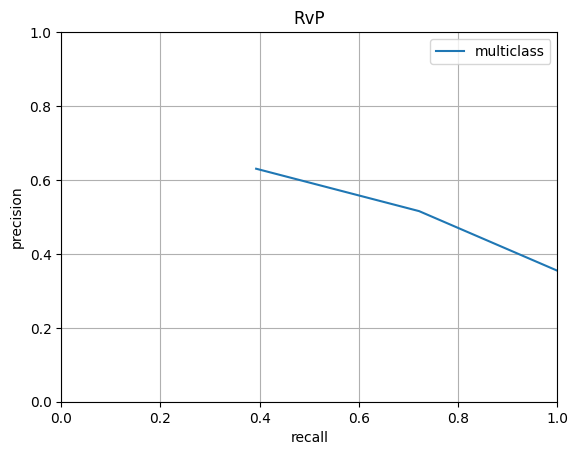

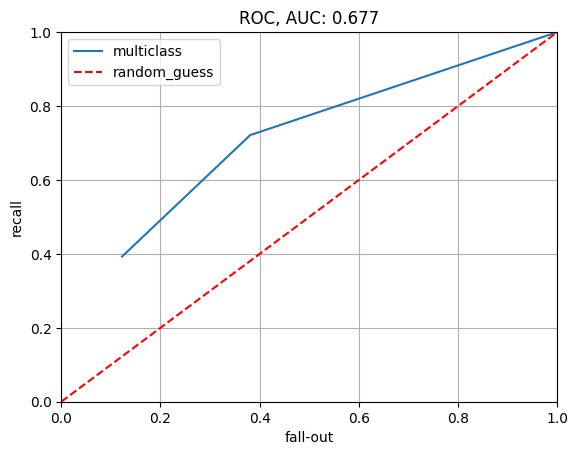

K: 5


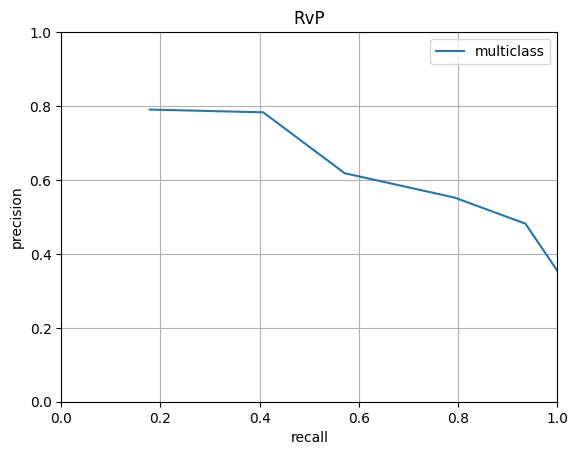

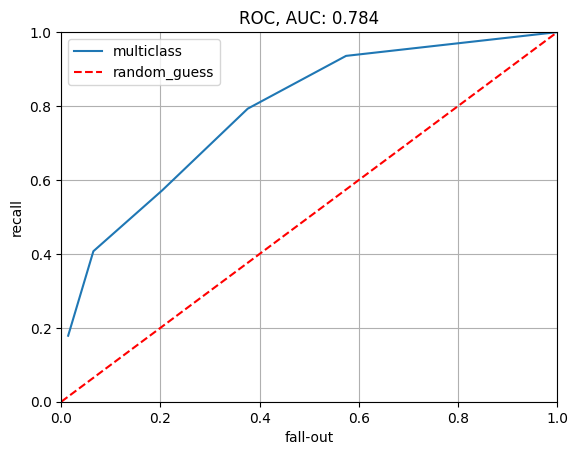

K: 20


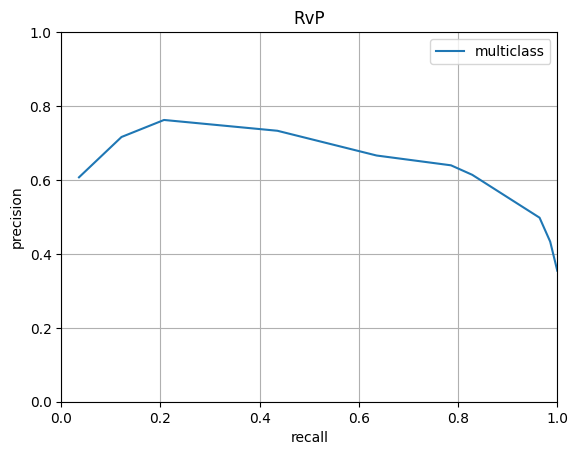

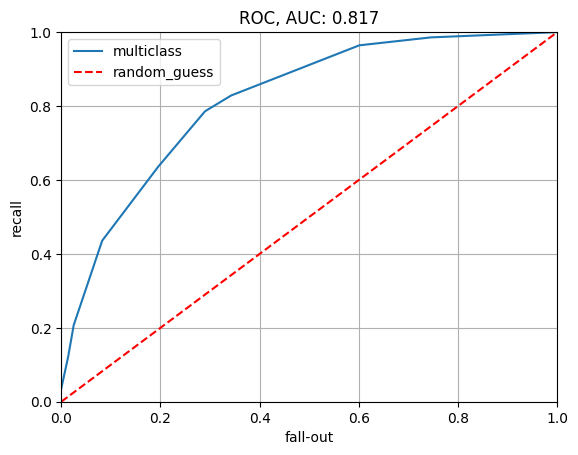

In [48]:
for k in [2, 5, 20]:
    print(f'K: {k}')
    knn.set_k(k)
    plot_measures(knn, y_unknown, all=False, plot_type='RvP')
    plot_measures(knn, y_unknown, all=False, plot_type='ROC')

In [49]:
##### DO NOT CHANGE #####
# ID: test-1-5-5-knn - possible points: 3

# Test for grading

# nn_targets should contain one row per unknown sample
assert knn.nn_targets.shape[0] == len(X_unknown), \
    "nn_targets has wrong number of rows"

# nn_targets should contain one column per labeled sample
assert knn.nn_targets.shape[1] == len(X_labeled), \
    "nn_targets has wrong number of columns"

# all neighbor labels should be valid training labels
assert np.all(np.isin(knn.nn_targets, y_labeled)), \
    "nn_targets contains invalid labels"

knn.set_k(5)

assert knn.knn_targets.shape == (len(X_unknown), 5), \
    "something wrong in knn_targets shape"

assert np.all(np.isin(knn.knn_targets, y_labeled)), \
    "knn_targets contains invalid labels"


#similar test as above, hidden


##### DO NOT CHANGE #####

In [50]:
##### DO NOT CHANGE #####
# ID: test-1-5-6-binary-metrics - possible points: 2

# Test for grading
knn = Knn_Classifier(X_unknown, X_labeled, y_labeled)
knn.set_k(5)

label = 1
threshold = 0.3

metrics = compute_binary_metrics(
    knn,
    label=label,
    ground_truth=y_unknown,
    threshold=threshold
)

for key in ["TP", "FP", "TN", "FN", "precision", "recall", "fall-out"]:
    assert key in metrics, f"missing metric {key}"

assert metrics["TP"] >= 0
assert metrics["FP"] >= 0
assert metrics["TN"] >= 0
assert metrics["FN"] >= 0

assert metrics["TP"] + metrics["FP"] + metrics["TN"] + metrics["FN"] == len(y_unknown), \
    "confusion matrix counts do not sum to number of test samples"

assert 0.0 <= metrics["precision"] <= 1.0
assert 0.0 <= metrics["recall"] <= 1.0
assert 0.0 <= metrics["fall-out"] <= 1.0

#similar test as above, hidden


##### DO NOT CHANGE #####

### 1.5.3 Dimensionality reduction with PCA

Now we will try to reduce the number of features to two and re-test the precision/recall curves from exercise 1.5.2.

We will try with an unsupervised method, namely via Principal Component Analysis (PCA). The task is to use `scikit-learn`'s implementation of PCA to reduce the feature space to two components and then to make a scatter plot of the new features, where the color of each point represents its class. Which property should this scatter plot have in order for the new features to be especially suitable for similarity search?

Implement a PCA model using the imported sklearn function and transform the features retaining only 2 components.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 1.5.7 (1 point).</strong> Use <code>sklearn</code>'s <code>PCA</code> to fit a 2-component model on <code>X_labeled</code> and transform <code>X_unknown</code> into <code>new_features_pca</code>.
</div>

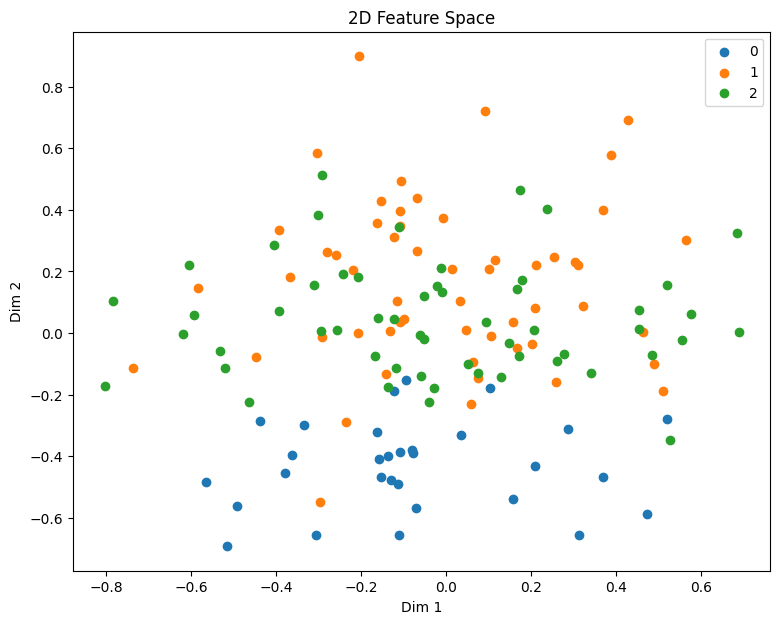

In [51]:
from sklearn.decomposition import PCA

pca = None
new_features_pca = None

# YOUR CODE HERE
pca = PCA(n_components=2)
pca.fit(X_labeled)
new_features_pca = pca.transform(X_unknown)

plt.figure(figsize=(9, 7))
for i in np.unique(y_unknown):
    plt.scatter(new_features_pca[y_unknown == i, 0], new_features_pca[y_unknown == i, 1], label=str(i))
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.title('2D Feature Space')
plt.legend()
plt.show()
plt.close()


In [52]:
##### DO NOT CHANGE #####
# ID: test-1-5-7-pca - possible points: 1

# Test for grading

# The task asks us to reduce the data to 2 components
assert new_features_pca.shape[-1] == 2, \
    "PCA should reduce features to 2 dimensions (as stated in the task)"

# PCA must preserve the number of samples
assert new_features_pca.shape[0] == X_unknown.shape[0], \
    "PCA output should have the same number of rows (samples) as the input"

# Sanity check: the output should have fewer columns than the input (otherwise PCA wasn't applied)
assert new_features_pca.shape[-1] < X_unknown.shape[-1], \
    "PCA output should have fewer columns than the input — was the PCA actually fitted/applied?"

#checking if correct number of components is retained in new_features_pca

##### DO NOT CHANGE #####

We fixed the number of components to be retained by the PCA to 2, so that we could easily visualize them with the scatter plot. What would be more sensible is to select a number of components sufficient enough to represent the variance of the data, in such a way to keep almost all valuable information carried by our features, but hopefully smaller than the total number of features, so to avoid redundancy. 

That's what we are doing next.

In [53]:
##### DO NOT CHANGE #####
pca = PCA()
pca.fit(X_labeled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_dim = next(ind for ind, x in enumerate(explained_variance) if x > .9)
print(f'Original number of features: {X_labeled.shape[-1]}')
print(f'Using only {n_dim} dimensions is enough to explain the 90% of the variance in the data')

##### DO NOT CHANGE #####

Original number of features: 3
Using only 2 dimensions is enough to explain the 90% of the variance in the data


Let's plot now the ROC curves of the knn classifier trained using all features and of the knn classifier with PCA reduced features. The performance improves only slightly in this specific example, but PCA reduction is a useful method to avoid overfitting in settings where the dimension of the dataset is small with respect to the dimension of the feature space.

ROC curve of knn classifier using all available features


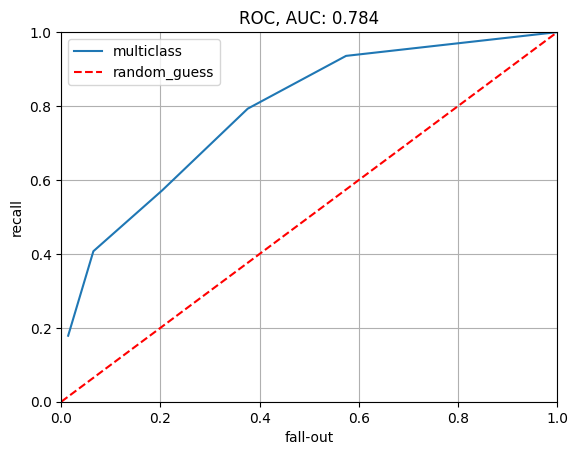

ROC curve of knn classifier using 2 most "important" features


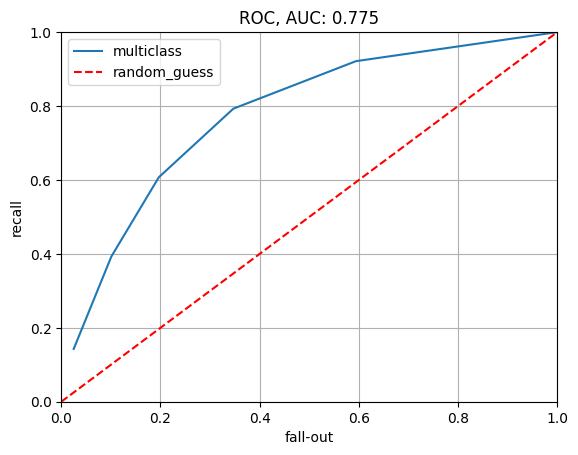

In [54]:
print('ROC curve of knn classifier using all available features')
knn = Knn_Classifier(X_unknown, X_labeled, y_labeled)
knn.set_k(5)
plot_measures(knn, y_unknown, all=False, plot_type='ROC')

print(f'ROC curve of knn classifier using {n_dim} most "important" features')
pca = PCA(n_components=n_dim)
pca.fit(X_labeled)
knn = Knn_Classifier(pca.transform(X_unknown), pca.transform(X_labeled), y_labeled)
knn.set_k(5)
plot_measures(knn, y_unknown, all=False, plot_type='ROC')

# Submitting your solution

As a last step, the notebook should be uploaded to Ilias such that we can grade it.